# Лабораторная работа №4

## Тема
Сравнение моделей классификации: логистическая регрессия, SVM и дерево решений.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, f1_score

RANDOM_STATE = 42
DATA_PATH = "../data/breast_cancer_wisconsin/data.csv"

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")
df["diagnosis"] = df["diagnosis"].replace({"M": 1, "B": 0})
df = df[df["diagnosis"].isin([0, 1])].copy()
df["diagnosis"] = df["diagnosis"].astype(int)

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [2]:
models = {
    "LogisticRegression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),
    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE))
    ]),
    "DecisionTree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=4))
    ])
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df

,model,accuracy,f1
1,SVM,0.973684,0.962963
0,LogisticRegression,0.964912,0.951220
2,DecisionTree,0.912281,0.871795


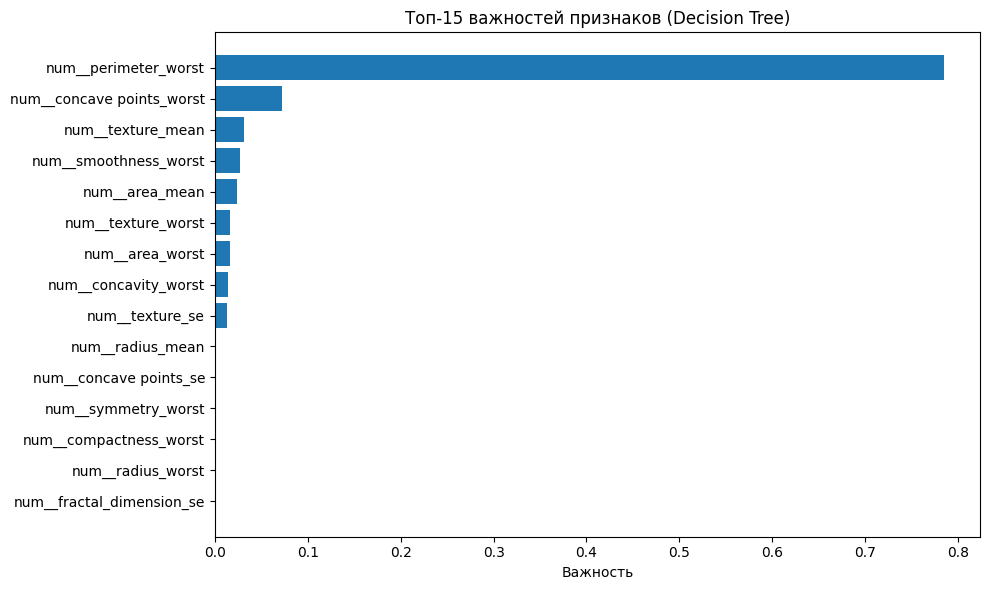

In [3]:
# Важность признаков для дерева решений
dt_pipeline = models["DecisionTree"]

dt_model = dt_pipeline.named_steps["model"]
feature_names = dt_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = dt_model.feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values(by="importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.gca().invert_yaxis()
plt.title("Топ-15 важностей признаков (Decision Tree)")
plt.xlabel("Важность")
plt.tight_layout()
plt.show()

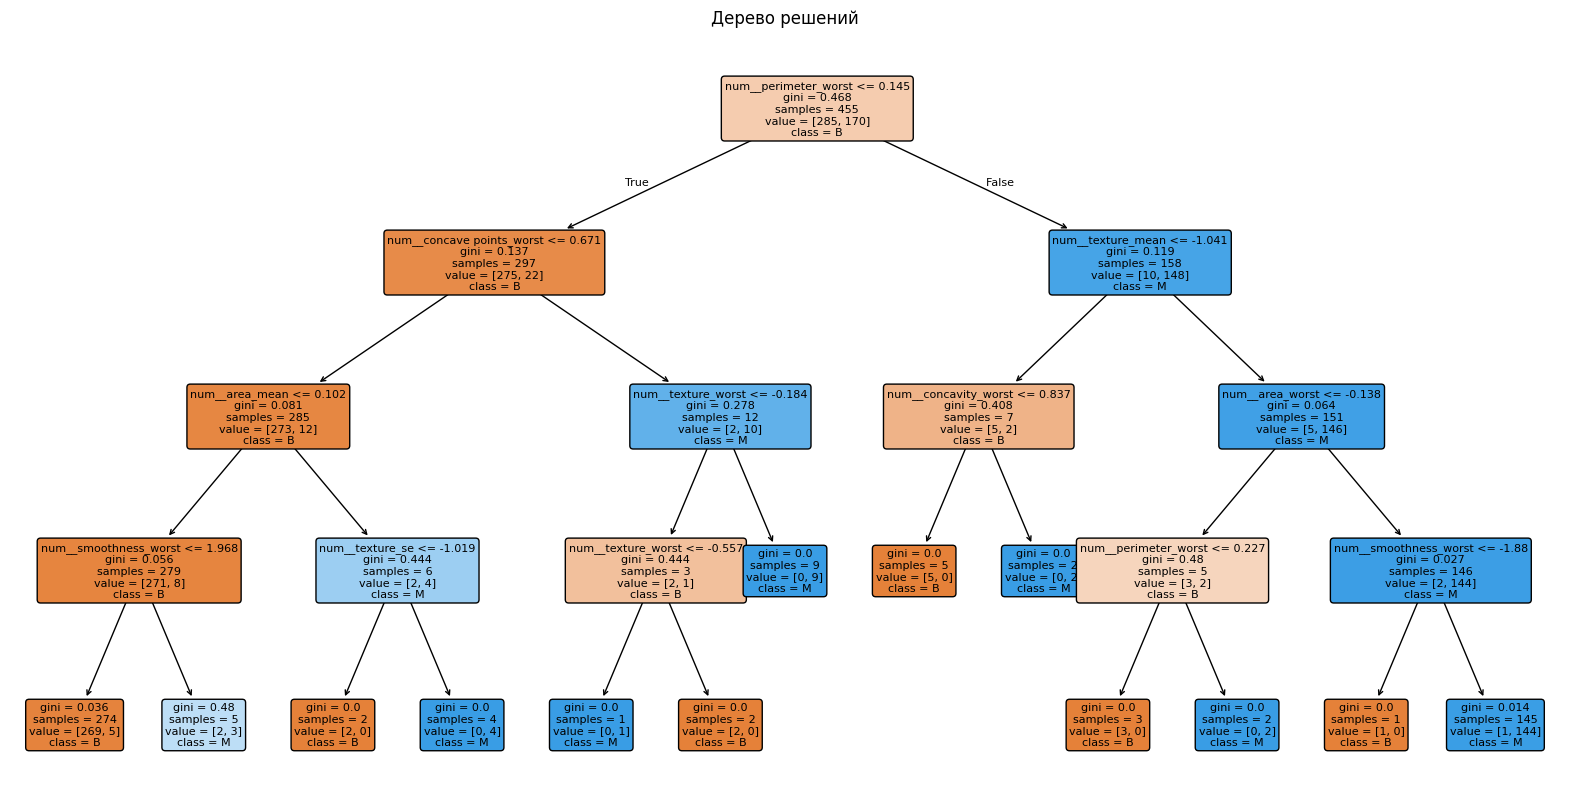

|--- num__perimeter_worst <= 0.14
|   |--- num__concave points_worst <= 0.67
|   |   |--- num__area_mean <= 0.10
|   |   |   |--- num__smoothness_worst <= 1.97
|   |   |   |   |--- class: 0
|   |   |   |--- num__smoothness_worst >  1.97
|   |   |   |   |--- class: 1
|   |   |--- num__area_mean >  0.10
|   |   |   |--- num__texture_se <= -1.02
|   |   |   |   |--- class: 0
|   |   |   |--- num__texture_se >  -1.02
|   |   |   |   |--- class: 1
|   |--- num__concave points_worst >  0.67
|   |   |--- num__texture_worst <= -0.18
|   |   |   |--- num__texture_worst <= -0.56
|   |   |   |   |--- class: 1
|   |   |   |--- num__texture_worst >  -0.56
|   |   |   |   |--- class: 0
|   |   |--- num__texture_worst >  -0.18
|   |   |   |--- class: 1
|--- num__perimeter_worst >  0.14
|   |--- num__texture_mean <= -1.04
|   |   |--- num__concavity_worst <= 0.84
|   |   |   |--- class: 0
|   |   |--- num__concavity_worst >  0.84
|   |   |   |--- class: 1
|   |--- num__texture_mean >  -1.04
|   |   |-

In [4]:
# Визуализация дерева и текстовые правила
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["B", "M"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Дерево решений")
plt.show()

print(export_text(dt_model, feature_names=list(feature_names)[:len(dt_model.feature_importances_)]))

## Выводы

Построены три модели классификации и выполнено сравнение по двум метрикам (`accuracy`, `f1`).
Дополнительно для дерева решений построен график важности признаков и получена визуализация структуры дерева с правилами.